In [1]:
# Autoreload
%load_ext autoreload
%autoreload 2

from optimizer import Optimizer
from chromosome import Chromosome
from character import Character
from utils import get_item_set, elements
import json

with open('data/MAPPED_ITEMS.json', 'r') as file:
    items = {i["ankama_id"]: i for i in json.load(file)}

with open('data/MAPPED_SETS.json', 'r') as file:
    item_sets = {i["ankama_id"]: i for i in json.load(file)}

In [2]:
config = {
            "optimizer" : {
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 1/3 of population size
                "num_generations": 50,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [6894,
                              6895,
                              3080,
                              9031,
                              6980 # Vulbis
                              ]  # Excluded items
                },
                "inclusions": {
                    "items": [
                        7754, # Dofus ocre
                    ]
                },
                "preferences": {
                    "lower": {
                        12: {
                            "target": 12,  # AP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        8: {
                            "target": 6,  # MP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        29: {
                            "target": 80,  # Crit
                            "strength": 0.75,  # Penalty for not meeting the target
                        },
                        9: {
                            "target": 4000,  # Vit
                            "strength": 0.5,  # Penalty for not meeting the target
                        },
                        34 : {
                            "target": 15, # %res neutral
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        37 : {
                            "target": 15, # %res fire
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        16 : {
                            "target": 15, # %res air
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        17 : {
                            "target": 15, # %res water
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        63 : {
                            "target": 15, # %res range
                            "strength": 0.1,  # Penalty for not meeting the target
                        }
                    },
                    "upper": {}
                },

                "level_offset": 10,  # Level offset for items
                "objective": "weapon"  # Objective to optimize, can be "weapon" or "elements"
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    12:1, # Exo AP
                    8:1
                    },  # Exo MP
                "distributed_points": {
                    9: 995,  # Vitality
                },
                "elements" : [
                    36, # Agility,
                    22, # Chance
                    13, # Intelligence
                    45  # Strength
                ],
                "melee" : False,
                "ranged" : True
            },
        }

In [3]:
import pandas as pd

effect_descriptions = {}
for _,item in items.items():
    if not item["effects"]:
        continue
    for effect in item["effects"]:
        effect_descriptions[effect["element_id"]] = effect["type"]

dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["optimizer"]["language"]],
        "set" : item_set["name"][config["optimizer"]["language"]] if item_set else None,
        "level" : v["level"]
    }
Items = pd.DataFrame.from_dict(dct, orient='index')

In [4]:
Items[Items["name"].str.contains("kuko",case=False)]

,name,set,level
13989,Pluma de kukoloide,None,200
14091,Amuleto de kukoloide,Set de kukoloide,200
14092,Anillo de kukoloide,Set de kukoloide,200
14093,Botas de kukoloide,Set de kukoloide,200
13988,Ojo de kukoloide,None,200
18718,Escudo de kukoloide,Set de kukoloide,200


In [5]:
char = Character(**config["character"])
opt = Optimizer(char,
                 items,
                   item_sets,
                     **config["optimizer"])

Total items: 2666
Total item sets: 148
Total pools:
   16 with sizes [69, 36, 71, 71, 62, 81, 40, 88, 69, 412, 1, 326, 326, 326, 326, 326]
Total combinations: 10^31.36


In [6]:
solutions = opt.optimize(islands = 10, max_workers = 4)

/Users/jdtibochab/miniconda3/envs/optimization/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/miniconda3/envs/optimization/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/miniconda3/envs/optimization/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solut

## PCA

In [ ]:
for idx, solution in enumerate(sorted(solutions, key=lambda x: x.fitness, reverse=True)):
    print(f"Solution {idx}:")
    print("\tFitness:", solution.get_fitness())
    print("\tWeapon damage:", solution.get_final_damage(type="weapon"))
    print("\tSpell damage:", solution.get_final_damage(type="elements"))
    print("\tIs the solution viable?", solution.viable)
    print("\tWas the solution penalized?", solution.penalized)

    print("\tPreferences:")
    df = solution.totals_summary(effect_descriptions)
    for bound, preference in solution.preferences.items():
        for element, details in preference.items():
            row = df.loc[element]
            print(f"\t\t{row['description']} : {row['value']}")
    print("\tCharacteristics:")
    for element in elements:
        print(f"\t\t{df.loc[element]['description']}: {df.loc[element]['value']}")

    print("\tItems:")
    print("\t\tType\tDescription\tLevel")
    for item,row in solution.set_summary().sort_values("type").iterrows():
        # Prettify the output
        print(f"\t\t{row['type']}\t{row['description']}\t{row['level']}")
    print("\tChromosome:")
    print("\t\t", solution.chromosome)

Solution 0:
	Fitness: 1299.0700000000002
	Weapon damage: 1299.0700000000002
\Spell damage: 1059.3400000000001
	Is the solution viable? True
	Was the solution penalized? False
	Preferences:
		PA : 12.0
		PM : 6.0
		% crítico : 81.0
		vitalidad : 4735.0
		% resistencia neutral : 25.0
		% resistencia al fuego : 28.0
		% resistencia al aire : 37.0
		% resistencia al agua : 35.0
		% resistencia a la tierra : 20.0
	Characteristics:
		agilidad: 240.0
		suerte: 340.0
		inteligencia: 410.0
		fuerza: 590.0
		vitalidad: 4735.0
		sabiduría: 440.0
	Items:
		Type	Description	Level
		Amuleto	Talismán Tira	200
		Anillo	Anillo del conde Kontatrás	200
		Anillo	Anillo de Corrupción	200
		Bota	Sandalias de Tal Kasha	200
		Capa	Capa Ordiosera	200
		Cinturón	Cinto Dovencible	200
		Dofus	Dofus Turquesa	160
		Dofus	Dofus Ocre	160
		Escudo	Escudo de kukoloide	200
		Guadaña	Hoz maldita del gran Desangrador Guerrero	200
		Mascotura	Kolifante mamuk	60
		Sombrero	Pendiente de Kongoku	200
		Trofeo	Destructor de tie

In [129]:
import pandas as pd
candidates = []
best_fitness = sorted(solutions, key=lambda x: x.fitness, reverse=True)[0].fitness
for sol in solutions:
    # Get list of solutions
    lst_solutions = sol.best_solutions
    lst_fitness = sol.best_solutions_fitness
    df = pd.DataFrame(lst_solutions)

    # Remove duplicates
    # 'keep' can be 'first', 'last', or False (mark all duplicates as True)
    unique_mask = ~df.duplicated(keep='first')
    unique_indices = df.index[unique_mask].to_list()
    unique_fitness = [lst_fitness[i] for i in unique_indices]

    # Filter candidates
    sorted_unique_indices = pd.Series({idx:f for idx, f in zip(unique_indices, unique_fitness)}).sort_values(ascending=False)
    candidate_indices = sorted_unique_indices.index[sorted_unique_indices.values >= 0.9 * best_fitness]
    for i in candidate_indices:
        candidates.append(lst_solutions[i])
print(f"Number of candidate solutions: {len(candidates)}")

Number of candidate solutions: 7


In [137]:
exclude = [179,225,72]
dct_totals = {}
lst_fitness = []
for idx,candidate in enumerate(candidates):
    chr = Chromosome(candidate,opt)
    if chr.penalized:
        continue
    dct_totals[idx] = chr.totals
    lst_fitness.append(chr.fitness)
df_totals = pd.DataFrame.from_dict(dct_totals, orient='index').fillna(0.)
df_totals = df_totals[[i for i in df_totals.columns if i not in exclude]]
df_totals.columns = df_totals.columns.map(lambda x: effect_descriptions.get(x, {}).get('es', x))

print(f"Number of valid solutions: {df_totals.shape[0]}")

Number of valid solutions: 7


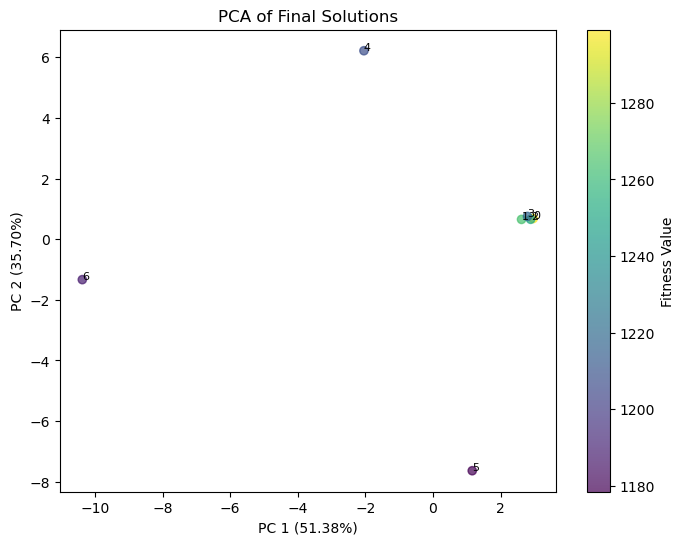

Gene contributions to each PC:


<Axes: >

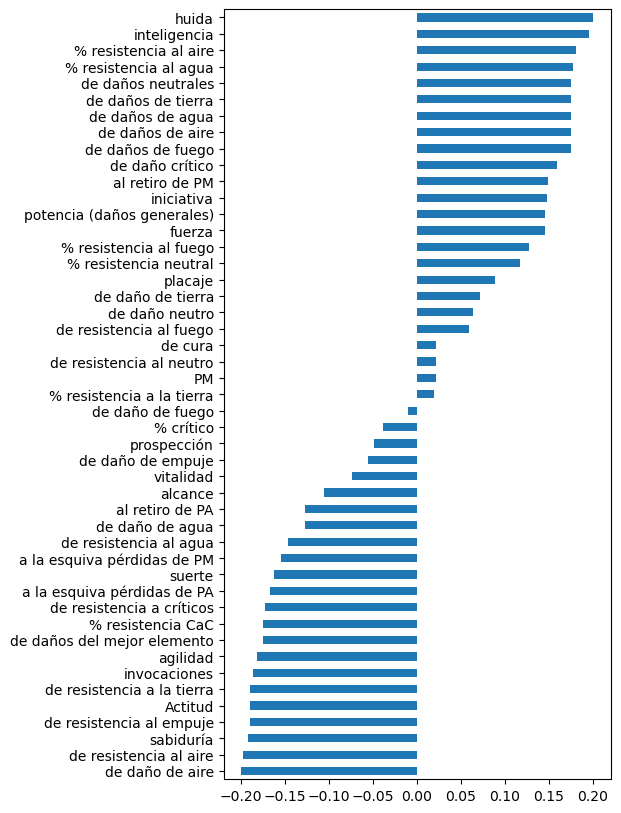

In [142]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# Suppose 'solutions' is your (n_solutions, n_genes) array
# solutions = np.array([...])

# Normalize totals
df_totals_normalized = (df_totals - df_totals.mean()) / df_totals.std()
df_totals_normalized = df_totals_normalized.dropna(axis=1)

# Run PCA
n_components = 2
pca = PCA(n_components=n_components)
principal_components = pca.fit_transform(df_totals_normalized.values)

# Visualize
plt.figure(figsize=(8,6))
# Mask data points with fitness value
# plt.scatter(principal_components[:,0], principal_components[:,1], alpha=0.7)
plt.scatter(principal_components[:,0], principal_components[:,1], c=lst_fitness, cmap='viridis', alpha=0.7)
plt.colorbar(label='Fitness Value')
# Plot the index of each point
for i in range(len(principal_components)):
    plt.annotate(i, (principal_components[i, 0], principal_components[i, 1]), fontsize=8)

# Calculate variance explained by each PC
explained_variance = pca.explained_variance_ratio_
plt.xlabel(f'PC 1 ({explained_variance[0]:.2%})')
plt.ylabel(f'PC 2 ({explained_variance[1]:.2%})')
plt.title('PCA of Final Solutions')
plt.show()

# Inspect contributions
gene_names = df_totals_normalized.columns.tolist()
pc_df = pd.DataFrame(pca.components_, columns=gene_names, index=[f"PC{i+1}" for i in range(n_components)])
print("Gene contributions to each PC:")
# pc_df.T.sort_values(by='PC1', ascending=True)
pc_df.T.sort_values(by='PC1', ascending=True)["PC1"].plot.barh(figsize=(5,10))

In [ ]:
assert False

AssertionError: 

In [ ]:
# Current
chr = Chromosome(
                 [
                    8993, # Espada
                    13641, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    14092, 14093, 18718, # Kuko
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 opt)
chr.fitness

2049.74

In [ ]:
Items[Items["name"].str.contains("kuko")]

,name,set,level
13989,Pluma de kukoloide,None,200
14091,Amuleto de kukoloide,Set de kukoloide,200
14092,Anillo de kukoloide,Set de kukoloide,200
14093,Botas de kukoloide,Set de kukoloide,200
13988,Ojo de kukoloide,None,200
18718,Escudo de kukoloide,Set de kukoloide,200


In [ ]:
chr.set_summary()

In [ ]:
chr.set_summary()["set"].value_counts()

In [ ]:
chr.totals_summary(effect_descriptions)

In [ ]:
Items[Items["name"].str.contains("Chani")]

In [ ]:
item = items[21392]
# item = items[6981]

In [ ]:
chr.are_item_conditions_met(item)

In [ ]:
item

In [ ]:
Items

In [ ]:
lst

In [ ]:
lst[0][2]

In [ ]:
chr.are_item_conditions_met(items[11738])

In [ ]:
items[11738]["conditions"]

In [ ]:
chr.totals[8]

In [ ]:
lst = []
for i in items.values():
    if i["type"]["superTypeId"] not in [i[0] for i in opt.pool_types]:
        continue
    if i["conditions"]:
        print(opt.solution.are_item_conditions_met(i))
        lst.append((i,opt.solution.are_item_conditions_met(i)))

In [ ]:
lst[1]

In [ ]:
lst.count(True), lst.count(False)